In [2]:
import sys
print(sys.executable)

c:\Users\Francisco\Documents\Documentos-secundario\Visual-Studio-Code-Repository\CT5108_Capstone\Unified_forecasting\.venv\Scripts\python.exe


### Libraries

In [3]:
import importlib.util
import subprocess
import sys
import itertools
from termcolor import colored

required = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "torch": "torch>=2.1",
    "tqdm": "tqdm>=4.65",
}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    print("missing packages: " + ", ".join(missing))

print("Environment ready")

Environment ready


In [4]:
from pathlib import Path
from types import SimpleNamespace
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, RobustScaler
from tqdm.auto import tqdm

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))
from models.DLinearCovariatesV1  import DLinearCovariatesV1
print(DLinearCovariatesV1)





device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


<class 'models.DLinearCovariatesV1.DLinearCovariatesV1'>


c:\Users\Francisco\Documents\Documentos-secundario\Visual-Studio-Code-Repository\CT5108_Capstone\Unified_forecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='cpu')

# DLinear with covariates

In [5]:
FEATURE_PATH = PROJECT_ROOT / "data/m5/processed/m5_long_features.parquet"
COMBINED_SPLIT_PATH = PROJECT_ROOT / "data/m5/processed/splits/combined_exclusive_series.csv"


### Prepare the grid of hyperparameters and scenarios

In [6]:
PRED_LEN = 28
BATCH_SIZE = 64
RANDOM_SEED = 42

# 0 means use all available series.
MAX_TRAIN_SERIES_PER_GROUP = 0
MAX_EVAL_SERIES_PER_GROUP = 0
EARLY_STOPPING_MIN_DELTA = 1e-5

GRID = {
    "seq_len": [28, 56, 112],
    "learning_rate": [1e-3, 3e-4],
    "epochs": [50],
    "samples_per_epoch": [10_000, 20_000, 40_000],
}

TRAIN_GROUPS = ["normal", "intermittent"]
EVAL_GROUPS = ["normal", "intermittent", "cold_start_item", "cold_start_store", "all_combined"]

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [7]:
TARGET_COLUMN = "log_sales"

COVARIATE_COLUMNS = [
    "day_of_week",
    "is_weekend",
    "event_flag",
    "snap_flag",
    "sell_price",
    #"price_change_pct",
]

MODEL_COLUMNS = [TARGET_COLUMN] + COVARIATE_COLUMNS
N_COVARIATES = len(COVARIATE_COLUMNS)
N_CHANNELS = len(MODEL_COLUMNS)

MODEL_COLUMNS

['log_sales',
 'day_of_week',
 'is_weekend',
 'event_flag',
 'snap_flag',
 'sell_price']

### Read data and prepare series

In [30]:
def sample_ids(series_ids, max_count, seed):
    # Convert the input to a normal Python list
    series_ids = list(series_ids)

    # If max_count is 0, None, or larger than the data, use all series
    if max_count is None or max_count <= 0 or max_count >= len(series_ids):
        return series_ids

    # Or sample a fixed number of series
    return (
        pd.Series(series_ids)
        .sample(n=max_count, random_state=seed)
        .astype(int)
        .tolist()
    )

#### Read data and set subsets

In [31]:
df_combined = pd.read_csv(COMBINED_SPLIT_PATH)

split_ids = {}

# Series ids for each subset
for split_name in ["normal", "intermittent", "cold_start_item", "cold_start_store"]:
    ids = (
        df_combined[df_combined["exclusive_split"] == split_name]["series_idx"]
        .dropna()
        .astype(int)
        .tolist()
    )

    split_ids[split_name] = sample_ids(
        ids,
        MAX_EVAL_SERIES_PER_GROUP,
        RANDOM_SEED,
    )

# Concatenate all individual exclusive subsets
split_ids["all_combined"] = (
    split_ids["normal"]
    + split_ids["intermittent"]
    + split_ids["cold_start_item"]
    + split_ids["cold_start_store"]
)

train_ids = []

# Series ids for training (only consider normal and intermittent series)
# cold-start is not used for training
for group_name in TRAIN_GROUPS:
    ids = (
        df_combined[df_combined["exclusive_split"] == group_name]["series_idx"]
        .dropna()
        .astype(int)
        .tolist()
    )

    train_ids.extend(
        sample_ids(
            ids,
            MAX_TRAIN_SERIES_PER_GROUP,
            RANDOM_SEED,
        )
    )

print("Train groups:", TRAIN_GROUPS)
print("Train series:", len(train_ids))

for split_name, ids in split_ids.items():
    print(split_name, len(ids))

Train groups: ['normal', 'intermittent']
Train series: 24696
normal 7600
intermittent 17096
cold_start_item 3050
cold_start_store 2744
all_combined 30490


#### Scaling covariates

In [32]:
def fit_covariate_scaler(series_ids, pred_len):
    scaler_df = pd.read_parquet(
        FEATURE_PATH,
        columns=["series_idx", "time_idx"] + COVARIATE_COLUMNS,
        filters=[("series_idx", "in", list(series_ids))],
    )

    scaler_df = scaler_df.sort_values(["series_idx", "time_idx"]).reset_index(drop=True)

    # Exclude the final validation horizon from scaler fitting.
    position_from_end = scaler_df.groupby("series_idx").cumcount(ascending=False)
    scaler_df = scaler_df[position_from_end >= pred_len]

    # Dealing with null and inf values
    covariates = (
        scaler_df[COVARIATE_COLUMNS]
        .replace([np.inf, -np.inf], 0)
        .fillna(0)
        .to_numpy(dtype=np.float32)
    )
    
    # scaler =  StandardScaler()
    scaler = RobustScaler()
    scaler.fit(covariates)

    return scaler

#Scaler is trained only using the training series
covariate_scaler = fit_covariate_scaler(train_ids, PRED_LEN)
covariate_scaler


,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"
,"copy copy: bool, default=TrueIf `False`, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"unit_variance unit_variance: bool, default=FalseIf `True`, scale data so that normally distributed features have avariance of 1. In general, if the difference between the x-values of`q_max` and `q_min` for a standard normal distribution is greaterthan 1, the dataset will be scaled down. If less than 1, the datasetwill be scaled up... versionadded:: 0.24",False


#### Load arrays

In [33]:
def load_series_arrays(series_ids, seq_len, pred_len, covariate_scaler):
    # Read parquet filtering columns
    df = pd.read_parquet(
        FEATURE_PATH,
        columns=["series_idx", "time_idx", "sales"] + MODEL_COLUMNS,
        filters=[("series_idx", "in", list(series_ids))],
    )
    df = df.sort_values(["series_idx", "time_idx"]).reset_index(drop=True)

    # Lists to store one array per time series.
    log_arrays = []
    sales_arrays = []
    clean_ids = []

    #Enough length validation
    minimum_length = seq_len + pred_len + pred_len

    # Create one log_sales array and one sales array for each series.
    for series_idx, group in df.groupby("series_idx", sort=True):
        group = group.sort_values("time_idx")
        
        log_series = group[[TARGET_COLUMN]].to_numpy(dtype=np.float32).copy()
        sales_series = group["sales"].to_numpy(dtype=np.float32).copy()
        
        # Dealing with null and inf values
        covariate_values = (
            group[COVARIATE_COLUMNS]
            .replace([np.inf, -np.inf], 0)
            .fillna(0)
            .to_numpy(dtype=np.float32)
            .copy()
        )
        # Scaling
        covariate_values = covariate_scaler.transform(covariate_values).astype(np.float32)

        model_values = np.concatenate([log_series, covariate_values], axis=1)

        # Keep only series with enough history and no missing log values.
        if len(model_values) >= minimum_length and not np.isnan(model_values).any():
            log_arrays.append(model_values)
            sales_arrays.append(sales_series)
            clean_ids.append(int(series_idx))

    return log_arrays, sales_arrays, clean_ids

### Windowing class for batch extraction

In [34]:
class RandomWindowDataset(Dataset):
    def __init__(self, series_arrays, seq_len, pred_len, samples_per_epoch, seed=42):
        self.series_arrays = series_arrays
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.samples_per_epoch = samples_per_epoch

        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return self.samples_per_epoch

    def __getitem__(self, index):
        # Choose one time series
        series_position = self.rng.integers(0, len(self.series_arrays))
        series = self.series_arrays[series_position]

        # Reserve the validation part of the window 
        validation_start = len(series) - self.pred_len

        max_start = validation_start - self.seq_len - self.pred_len

        # Choose window
        start = self.rng.integers(0, max_start + 1)

        # Input window and target window
        x = series[start : start + self.seq_len].copy()
        y = series[start + self.seq_len : start + self.seq_len + self.pred_len,
            0:1,].copy()

        return torch.from_numpy(x), torch.from_numpy(y)

### Validation series function and evaluation metrics

In [35]:
def build_validation_tensors(series_arrays_log, series_arrays_sales, seq_len, pred_len):
    x_values = []
    y_log_values = []
    y_sales_values = []

    # One validation example for each series
    for log_series, sales_series in zip(series_arrays_log, series_arrays_sales):
        #validation start number
        validation_start = len(log_series) - pred_len

        x = log_series[validation_start - seq_len : validation_start]
        y_log = log_series[validation_start : validation_start + pred_len, 0:1] #First channel
        y_sales = sales_series[validation_start : validation_start + pred_len]

        x_values.append(x)
        y_log_values.append(y_log)
        y_sales_values.append(y_sales)

    # Turn lists into arrays
    return (
        np.stack(x_values).astype(np.float32),
        np.stack(y_log_values).astype(np.float32),
        np.stack(y_sales_values).astype(np.float32),
    )

In [36]:
def calculate_metrics(pred_sales, actual_sales, zero_tresh=0.5):
    mae = np.mean(np.abs(pred_sales - actual_sales))                                            # sum(abs(y_hat - y)) / n
    rmse = np.sqrt(np.mean((pred_sales - actual_sales) ** 2))                                   # sqrt(  sum((y_hat - y)^2) / n  )
    wape = np.sum(np.abs(pred_sales - actual_sales)) / (np.sum(np.abs(actual_sales)) + 1e-8)    #  sum(abs(y_hat - y))   /   sum(abs(y))

    actual_zero = actual_sales == 0
    predicted_zero = pred_sales < zero_tresh
    
    true_positive = np.sum(predicted_zero & actual_zero)
    false_positive = np.sum(predicted_zero & ~actual_zero)
    false_negative = np.sum(~predicted_zero & actual_zero)

    zero_precision = true_positive / (true_positive + false_positive + 1e-8)    # tp / (tp + fp)
    zero_recall = true_positive / (true_positive + false_negative + 1e-8)       # tp / (tp + fn)
    zero_f1 = (
        2 * zero_precision * zero_recall
        / (zero_precision + zero_recall + 1e-8)
    )                                                                           # 2*P*R / (P + R)
    
    
    return {
        "mae": float(mae),
        "rmse": float(rmse),
        "wape": float(wape),
        "zero_precision": float(zero_precision),
        "zero_recall": float(zero_recall),
        "zero_f1": float(zero_f1)
        
    }

### Evaluation function

In [37]:
def evaluate_model_on_subset(model, subset_name, log_arrays, sales_arrays, seq_len, pred_len):
    # Validation data
    x_val, y_val_log, actual_sales = build_validation_tensors(
        log_arrays,
        sales_arrays,
        seq_len,
        pred_len,
    )

    # Evaluation mode
    model.eval()

    # Predict
    with torch.no_grad():
        x_tensor = torch.from_numpy(x_val.copy()).to(device)
        pred_log = model(x_tensor).cpu().numpy().squeeze(-1)

    # Change log_sales prediction to sales
    pred_sales = np.expm1(pred_log)
    pred_sales = np.clip(pred_sales, 0, None)

    #Baseline 1: Last value
    last_value_forecast = np.repeat(x_val[:, -1:, 0], pred_len, axis=1)
    last_value_forecast = np.expm1(last_value_forecast)

    #Baseline 2: Repeat the previous pred_len observations
    seasonal_naive_forecast = []
    for sales_series in sales_arrays:
        validation_start = len(sales_series) - pred_len
        previous_n_days = sales_series[validation_start - pred_len : validation_start]
        seasonal_naive_forecast.append(previous_n_days)
    seasonal_naive_forecast = np.stack(seasonal_naive_forecast)
    
    #Baseline 3: Predict all 0
    zero_forecast = np.zeros_like(actual_sales)

    return {
        "zero": calculate_metrics(zero_forecast, actual_sales),
        "last_value": calculate_metrics(last_value_forecast, actual_sales),
        "seasonal_naive_28": calculate_metrics(seasonal_naive_forecast, actual_sales),
        "global_dlinear": calculate_metrics(pred_sales, actual_sales),
    }

### Training and setting model parameters

In [38]:
def train_global_dlinear_covariates(train_log_arrays, seq_len, pred_len, 
                         learning_rate, epochs, samples_per_epoch, min_delta=1e-4):
    # Call window generator for training batches
    train_dataset = RandomWindowDataset(
        series_arrays=train_log_arrays,
        seq_len=seq_len,
        pred_len=pred_len,
        samples_per_epoch=samples_per_epoch,
        seed=RANDOM_SEED
    )

    #Group into batches
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0
    )

    # TODO: Replace univariate DLinear with a multivariate
    model = DLinearCovariatesV1(
            seq_len=seq_len,
            pred_len=pred_len,
            n_covariates=N_COVARIATES
    ).to(device)

    # Adam optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    # MSE as loss function
    loss_fn = torch.nn.MSELoss()

    best_train_loss = float("inf")
    best_state = None
    best_epoch = None
    previous_train_loss = None
    training_history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for x, y in tqdm(train_loader, desc=f"seq={seq_len}, lr={learning_rate}, epoch={epoch}"):
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            prediction = model(x) # Forward pass
            loss = loss_fn(prediction, y) # Training loss
            loss.backward() # Gradients backpropagation
            optimizer.step() # Update weights

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        
        training_history.append({
            "epoch": epoch,
            "train_mse_log": train_loss,
        })

        # Save model weights if has the best training loss
        if train_loss < best_train_loss:
            best_train_loss = train_loss
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
        
        if previous_train_loss is not None:
            loss_difference = abs(previous_train_loss - train_loss)

            if loss_difference < min_delta:
                print(
                    f"Early stopping at epoch {epoch}. "
                    f"Loss difference: {loss_difference:.6f}"
                )
                break

        previous_train_loss = train_loss

    # Set model weights using the epoch with lowest loss
    model.load_state_dict(best_state)

    return model, best_epoch, best_train_loss, len(training_history), training_history

### Grid search

In [48]:
%%capture

all_results = []

# List of all hyperparameters combinations
grid_combinations = list(itertools.product(
    GRID["seq_len"],
    GRID["learning_rate"],
    GRID["epochs"],
    GRID["samples_per_epoch"],
))

# Train and evaluate every grid search combination
for seq_len, learning_rate, epochs, samples_per_epoch in grid_combinations: #grid_combinations: # [grid_combinations[0]]:
    print(colored("\n----Grid run----",  'green', attrs=['bold']))
    print("seq_len:", colored(seq_len, attrs=['bold']))
    print("learning_rate:", colored(learning_rate, attrs=['bold']))
    print("epochs:", colored(epochs, attrs=['bold']))
    print("samples_per_epoch:", colored(samples_per_epoch, attrs=['bold']) )

    # Get training series
    train_log_arrays, train_sales_arrays, clean_train_ids = load_series_arrays(
        train_ids,
        seq_len,
        PRED_LEN,
        covariate_scaler
    )

    print("\nLoaded train series:", len(train_log_arrays))

    #Training phase one model for each combinations
    model, best_epoch, best_train_loss, epochs_ran, training_history = train_global_dlinear_covariates(
        train_log_arrays=train_log_arrays,
        seq_len=seq_len,
        pred_len=PRED_LEN,
        learning_rate=learning_rate,
        epochs=epochs,
        samples_per_epoch=samples_per_epoch,
        min_delta=EARLY_STOPPING_MIN_DELTA
    )

    # evaluate each subset
    for subset_name in EVAL_GROUPS:
        eval_log_arrays, eval_sales_arrays, clean_eval_ids = load_series_arrays(
            split_ids[subset_name],
            seq_len,
            PRED_LEN,
            covariate_scaler
        )

        subset_metrics = evaluate_model_on_subset(
            model=model,
            subset_name=subset_name,
            log_arrays=eval_log_arrays,
            sales_arrays=eval_sales_arrays,
            seq_len=seq_len,
            pred_len=PRED_LEN,
        )

        # One record per subset -- model (including baselines) -- grid of hyperparameters
        for model_name, metrics in subset_metrics.items():
            all_results.append({
                "train_groups": "+".join(TRAIN_GROUPS),
                "subset": subset_name,
                "model": model_name,
                "seq_len": seq_len,
                "pred_len": PRED_LEN,
                "learning_rate": learning_rate,
                "early_stop_delta": EARLY_STOPPING_MIN_DELTA,
                "epochs": epochs,
                "epochs_ran": epochs_ran,
                "samples_per_epoch": samples_per_epoch,
                "batch_size": BATCH_SIZE,
                "best_epoch": best_epoch,
                "best_train_mse_log": best_train_loss,
                "n_train_series": len(train_log_arrays),
                "n_eval_series": len(eval_log_arrays),
                "mae": metrics["mae"],
                "rmse": metrics["rmse"],
                "wape": metrics["wape"],
                "zero_precision": metrics["zero_precision"],
                "zero_recall": metrics["zero_recall"],
                "zero_f1": metrics["zero_f1"]
            })
    print(colored("----------------------------",  'green', attrs=['bold']))

results_df = pd.DataFrame(all_results)
results_df

In [12]:
output_path = PROJECT_ROOT / "notebooks/Results/dlinear_covariates_v1_grid_results.csv"

results_df = pd.read_csv(output_path)

In [13]:
results_df.sort_values(
    ["subset", "wape"],
    ascending=[True, True],
).reset_index(drop=True)

,train_groups,subset,model,seq_len,pred_len,learning_rate,early_stop_delta,epochs,epochs_ran,samples_per_epoch,...,best_epoch,best_train_mse_log,n_train_series,n_eval_series,mae,rmse,wape,zero_precision,zero_recall,zero_f1
0,normal+intermittent,all_combined,global_dlinear,56,28,0.0003,0.00001,50,45,10000,...,36,0.196918,24696,30490,1.000452,2.315412,0.721601,0.760510,0.756313,0.758406
1,normal+intermittent,all_combined,global_dlinear,28,28,0.0003,0.00001,50,50,10000,...,36,0.196109,24696,30490,1.002620,2.338686,0.723165,0.759235,0.760307,0.759771
2,normal+intermittent,all_combined,global_dlinear,28,28,0.0003,0.00001,50,50,40000,...,43,0.200545,24696,30490,1.007077,2.311839,0.726379,0.769724,0.733709,0.751285
3,normal+intermittent,all_combined,global_dlinear,112,28,0.0003,0.00001,50,50,20000,...,41,0.200263,24696,30490,1.008161,2.356390,0.727162,0.763795,0.749317,0.756487
4,normal+intermittent,all_combined,global_dlinear,56,28,0.0003,0.00001,50,50,20000,...,16,0.200475,24696,30490,1.009319,2.345954,0.727997,0.761457,0.752670,0.757038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,normal+intermittent,normal,zero,112,28,0.0010,0.00001,50,50,20000,...,41,0.208735,24696,7600,2.986988,6.206973,1.000000,0.314831,1.000000,0.478892
356,normal+intermittent,normal,zero,112,28,0.0010,0.00001,50,50,40000,...,24,0.212464,24696,7600,2.986988,6.206973,1.000000,0.314831,1.000000,0.478892
357,normal+intermittent,normal,zero,112,28,0.0003,0.00001,50,50,10000,...,36,0.202497,24696,7600,2.986988,6.206973,1.000000,0.314831,1.000000,0.478892
358,normal+intermittent,normal,zero,112,28,0.0003,0.00001,50,50,20000,...,41,0.200263,24696,7600,2.986988,6.206973,1.000000,0.314831,1.000000,0.478892


In [14]:
best_dlinear_by_subset = (
    results_df[results_df["model"] == "global_dlinear"]
    .sort_values(["subset", "wape"])
    .groupby("subset", as_index=False)
    .first()
)

best_dlinear_by_subset

,subset,train_groups,model,seq_len,pred_len,learning_rate,early_stop_delta,epochs,epochs_ran,samples_per_epoch,...,best_epoch,best_train_mse_log,n_train_series,n_eval_series,mae,rmse,wape,zero_precision,zero_recall,zero_f1
0,all_combined,normal+intermittent,global_dlinear,56,28,0.0003,0.00001,50,45,10000,...,36,0.196918,24696,30490,1.000452,2.315412,0.721601,0.760510,0.756313,0.758406
1,cold_start_item,normal+intermittent,global_dlinear,56,28,0.0003,0.00001,50,45,10000,...,36,0.196918,24696,3050,1.120219,2.671217,0.711742,0.750950,0.728889,0.739755
2,cold_start_store,normal+intermittent,global_dlinear,56,28,0.0003,0.00001,50,45,10000,...,36,0.196918,24696,2744,1.054682,2.311533,0.714693,0.758165,0.714449,0.735658
3,intermittent,normal+intermittent,global_dlinear,56,28,0.0010,0.00001,50,50,10000,...,36,0.201024,24696,17096,0.590676,1.231432,0.941867,0.763105,0.882853,0.818623
4,normal,normal+intermittent,global_dlinear,28,28,0.0003,0.00001,50,50,40000,...,43,0.200545,24696,7600,1.824089,3.663566,0.610678,0.643295,0.311825,0.420042


## Explore results

In [15]:
scatter_df = results_df.copy()

subsets_order = [
    "normal",
    "intermittent",
    "cold_start_item",
    "cold_start_store",
    "all_combined",
]

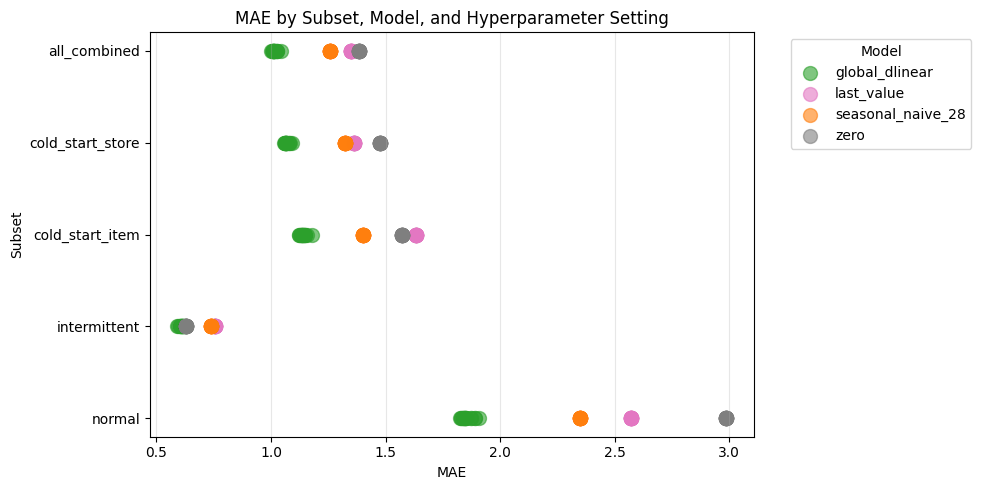

In [16]:
model_colors = {
    "zero": "tab:gray",
    "last_value": "tab:pink",
    "seasonal_naive_28": "tab:orange",
    "global_dlinear": "tab:green",
}

# Convert categorical to numeric y positions.
subset_to_y = {subset: i for i, subset in enumerate(subsets_order)}
scatter_df["subset_y"] = scatter_df["subset"].map(subset_to_y)

plt.figure(figsize=(10, 5))

# add each observation
for model_name, model_data in scatter_df.groupby("model"):
    plt.scatter(
        model_data["mae"],
        model_data["subset_y"],
        label=model_name,
        color=model_colors.get(model_name),
        alpha=0.6,
        s=100,
    )

# Set the y axis labels https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.yticks.html
plt.yticks(
    ticks=range(len(subsets_order)),
    labels=subsets_order,
)

plt.xlabel("MAE")
plt.ylabel("Subset")
plt.title("MAE by Subset, Model, and Hyperparameter Setting")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# output_path = PROJECT_ROOT / "notebooks/Results/dlinear_covariates_v1_grid_results.csv"

# results_df.to_csv(output_path, index=False)

# output_path

WindowsPath('c:/Users/Francisco/Documents/Documentos-secundario/Visual-Studio-Code-Repository/CT5108_Capstone/Unified_forecasting/notebooks/Results/dlinear_covariates_v1_grid_results.csv')

### Compare with DLinear baseline

In [17]:
previous_results_path = (
    PROJECT_ROOT / "notebooks/Results/dlinear_v1_grid_results.csv"
)

if previous_results_path.exists():
    previous_results = pd.read_csv(previous_results_path)

    previous_best = (
        previous_results[previous_results["model"] == "global_dlinear"]
        .sort_values(["subset", "wape"])
        .groupby("subset", as_index=False)
        .first()[["subset", "mae", "rmse", "wape", "zero_f1"]]
        .rename(columns={
            "mae": "dlinear_mae",
            "rmse": "dlinear_rmse",
            "wape": "dlinear_wape",
            "zero_f1": "dlinear_zero_f1",
        })
    )

    future_best = best_dlinear_by_subset[
        ["subset", "mae", "rmse", "wape", "zero_f1"]
    ].rename(columns={
        "mae": "past_covariates_mae",
        "rmse": "past_covariates_rmse",
        "wape": "past_covariates_wape",
        "zero_f1": "past_covariates_zero_f1",
    })

    comparison_df = previous_best.merge(future_best, on="subset")
    comparison_df["wape_change"] = (
        comparison_df["past_covariates_wape"]
        - comparison_df["dlinear_wape"]
    )

    comparison_df
else:
    print("Previous result file not found:", previous_results_path)


In [18]:
comparison_df

,subset,dlinear_mae,dlinear_rmse,dlinear_wape,dlinear_zero_f1,past_covariates_mae,past_covariates_rmse,past_covariates_wape,past_covariates_zero_f1,wape_change
0,all_combined,1.007825,2.340267,0.726919,0.757454,1.000452,2.315412,0.721601,0.758406,-0.005319
1,cold_start_item,1.126989,2.702959,0.716044,0.738572,1.120219,2.671217,0.711742,0.739755,-0.004302
2,cold_start_store,1.061490,2.346595,0.719307,0.738157,1.054682,2.311533,0.714693,0.735658,-0.004613
3,intermittent,0.602921,1.223303,0.961393,0.815499,0.590676,1.231432,0.941867,0.818623,-0.019526
4,normal,1.843146,3.705678,0.617059,0.436294,1.824089,3.663566,0.610678,0.420042,-0.006380


In [19]:
improvement_summary = comparison_df[["subset"]].copy()

# For error measures, a reduction is an improvement.
for metric in ["mae", "rmse", "wape"]:
    past = comparison_df[f"dlinear_{metric}"]
    future = comparison_df[f"past_covariates_{metric}"]

    improvement_summary[f"{metric}_improvement_pct"] = (
        100 * (past - future) / (past + 1e-8)
    )

# For F1, an increase is an improvement.
past_f1 = comparison_df["dlinear_zero_f1"]
future_f1 = comparison_df["past_covariates_zero_f1"]

improvement_summary["zero_f1_improvement_pct"] = (
    100 * (future_f1 - past_f1) / (past_f1 + 1e-8)
)

improvement_summary.round(2)

#2_dlinear_covariates vs dlinear

,subset,mae_improvement_pct,rmse_improvement_pct,wape_improvement_pct,zero_f1_improvement_pct
0,all_combined,0.73,1.06,0.73,0.13
1,cold_start_item,0.60,1.17,0.60,0.16
2,cold_start_store,0.64,1.49,0.64,-0.34
3,intermittent,2.03,-0.66,2.03,0.38
4,normal,1.03,1.14,1.03,-3.73
